# Лабораторная работа. XAI и Интерпретируемые модели: Wine Quality (мультиклассовая классификация)

**Автор:** : Жунёв Андрей РИМ-150950

**Цель:** Продемонстрировать полный пайплайн мультиклассовой классификации качества красного вина: от EDA и обучения моделей до глобальной и локальной интерпретации.

**Набор данных:** [Wine Quality (Red Wine Dataset)](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv)  
**Источник:** UCI Machine Learning Repository  
**Размер:** 1599 образцов × 12 признаков  
**Целевая переменная:** `quality` (оценка 3–8 баллов, 6 классов)

**Модели:** `RandomForestClassifier` (бэггинг над деревьями) и `CatBoostClassifier` (градиентный бустинг).


## Оглавление

1. [I. Загрузка и подготовка данных (EDA)](#I.-Загрузка-и-подготовка-данных-(EDA))
2. [II. Предварительная обработка данных](#II.-Предварительная-обработка-данных)
3. [III. Обучение базовых моделей](#III.-Обучение-базовых-моделей)
   - [1. Метрики для сравнения моделей](#1.-Метрики-для-сравнения-моделей)
   - [2. Выбор моделей](#2.-Выбор-моделей)
   - [3. Обучение Random Forest (базовая модель)](#3.-Обучение-Random-Forest-(базовая-модель))
   - [4. Обучение CatBoost (базовая модель)](#4.-Обучение-CatBoost-(базовая-модель))
   - [5. Сравнение базовых моделей](#5.-Сравнение-базовых-моделей)
4. [IV. Оптимизация выбранных моделей](#IV.-Оптимизация-выбранных-моделей)
   - [1. Оптимизация Random Forest (Optuna)](#1.-Оптимизация-Random-Forest-(Optuna))
   - [2. Оптимизация CatBoost (Optuna)](#2.-Оптимизация-CatBoost-(Optuna))
5. [V. Итоговое сравнение и анализ ошибок](#V.-Итоговое-сравнение-и-анализ-ошибок)
   - [1. Сводная таблица результатов](#1.-Сводная-таблица-результатов)
   - [2. Матрица ошибок (Confusion Matrix)](#2.-Матрица-ошибок-(Confusion-Matrix))
   - [3. ROC-кривые по классам](#3.-ROC-кривые-по-классам)
   - [4. Анализ пересечения ошибок](#4.-Анализ-пересечения-ошибок)
6. [VI. Интерпретируемость (XAI)](#VI.-Интерпретируемость-(XAI))
   - [1. Глобальная интерпретация](#1.-Глобальная-интерпретация)
   - [2. Локальная интерпретация](#2.-Локальная-интерпретация)
7. [VII. Выводы](#VII.-Выводы)


## Импорты

> **Hint:** Запустите эту ячейку один раз перед началом работы. Здесь же определены все вспомогательные функции, которые используются во всех разделах.


In [22]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoostClassifier, Pool

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

px.defaults.template = 'plotly_white'

print('✅ Все библиотеки успешно импортированы')


✅ Все библиотеки успешно импортированы


In [23]:
# ============================================================================
# ГЛОБАЛЬНЫЙ СПИСОК ДЛЯ ХРАНЕНИЯ РЕЗУЛЬТАТОВ ВСЕХ МОДЕЛЕЙ
# ============================================================================
MODEL_RESULTS = []


def calculate_multiclass_metrics(y_true, y_pred, y_proba):
    '''Вычисляет четыре ключевые метрики для мультиклассовой классификации.

    Параметры
    ----------
    y_true  : array-like, истинные метки (закодированные 0..K-1)
    y_pred  : array-like, предсказанные метки
    y_proba : array-like, матрица вероятностей (n_samples, n_classes)

    Возвращает
    ----------
    dict с ключами: Balanced Accuracy, F1 Macro, F1 Weighted, ROC AUC (OvR)
    '''
    return {
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'F1 Macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'F1 Weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'ROC AUC (OvR)':     roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
    }


def add_result(model_name, features_desc, model, X_train, y_train, X_test, y_test):
    '''Обучает предсказания и сохраняет метрики в глобальный MODEL_RESULTS.

    Параметры
    ----------
    model_name    : str   — название модели
    features_desc : str   — описание набора признаков
    model         : fitted estimator
    X_train, y_train, X_test, y_test : данные
    '''
    y_train_pred  = np.array(model.predict(X_train)).flatten()
    y_test_pred   = np.array(model.predict(X_test)).flatten()
    y_train_proba = model.predict_proba(X_train)
    y_test_proba  = model.predict_proba(X_test)

    m_train = calculate_multiclass_metrics(y_train, y_train_pred, y_train_proba)
    m_test  = calculate_multiclass_metrics(y_test,  y_test_pred,  y_test_proba)

    gap = m_train['Balanced Accuracy'] - m_test['Balanced Accuracy']

    MODEL_RESULTS.append({
        'Model':              model_name,
        'Features':           features_desc,
        'Bal.Acc Train':      round(m_train['Balanced Accuracy'], 4),
        'Bal.Acc Test':       round(m_test['Balanced Accuracy'],  4),
        'Gap (Bal.Acc)':      round(gap, 4),
        'F1 Macro Train':     round(m_train['F1 Macro'], 4),
        'F1 Macro Test':      round(m_test['F1 Macro'],  4),
        'F1 Weighted Test':   round(m_test['F1 Weighted'], 4),
        'ROC AUC Test':       round(m_test['ROC AUC (OvR)'], 4),
    })

    if gap > 0.1:
        print(f'⚠️  {model_name}: возможное переобучение (Gap Bal.Acc = {gap:.4f})')
    else:
        print(f'✅ {model_name}: переобучение незначительное (Gap = {gap:.4f})')


print('✅ Функции calculate_multiclass_metrics() и add_result() созданы')


✅ Функции calculate_multiclass_metrics() и add_result() созданы


In [24]:
def plot_model_report_separate(
    metrics_dict,
    feature_importance,
    model_name,
    width_metrics=850,
    height_metrics=450,
    width_fi=800,
    height_fi=550,
):
    '''Строит два отдельных Plotly-графика: метрики Train vs Test и важность признаков.

    Параметры
    ----------
    metrics_dict : dict с ключами 'train' и 'test', каждый — dict метрик
    feature_importance : pd.DataFrame с колонками ['feature', 'importance'] или None
    model_name   : str
    '''
    metric_names = ['Balanced Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC AUC (OvR)']
    train_vals   = [metrics_dict['train'].get(m, 0) for m in metric_names]
    test_vals    = [metrics_dict['test'].get(m, 0)  for m in metric_names]

    fig_m = go.Figure()
    fig_m.add_trace(go.Bar(
        name='Train', x=metric_names, y=train_vals,
        marker_color='steelblue',
        text=[f'{v:.4f}' for v in train_vals], textposition='auto',
    ))
    fig_m.add_trace(go.Bar(
        name='Test', x=metric_names, y=test_vals,
        marker_color='crimson',
        text=[f'{v:.4f}' for v in test_vals], textposition='auto',
    ))
    fig_m.update_layout(
        title={'text': f'Метрики качества: {model_name}', 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Метрика', yaxis_title='Значение',
        barmode='group', template='plotly_white',
        width=width_metrics, height=height_metrics,
        legend_title_text='Split',
        yaxis=dict(range=[0, 1.05]),
    )
    fig_m.show()

    if feature_importance is not None and len(feature_importance) > 0:
        fi = feature_importance.copy().sort_values('importance', ascending=True)
        fig_fi = go.Figure()
        fig_fi.add_trace(go.Bar(
            x=fi['importance'], y=fi['feature'],
            orientation='h', marker_color='coral',
        ))
        fig_fi.update_layout(
            title={'text': f'Важность признаков: {model_name}', 'x': 0.5, 'xanchor': 'center'},
            xaxis_title='Важность', yaxis_title='Признак',
            template='plotly_white', width=width_fi, height=height_fi, showlegend=False,
        )
        fig_fi.show()


print('✅ Функция plot_model_report_separate() создана')


✅ Функция plot_model_report_separate() создана


In [25]:
def add_wine_features(df):
    '''Добавляет 5 синтетических химических признаков к данным вина.

    Новые признаки:
    - total_acidity     : сумма всех кислот (fixed + volatile + citric)
    - vol_fixed_ratio   : отношение летучей к постоянной кислотности
    - free_so2_ratio    : доля свободного SO2 от общего
    - alc_density_prod  : произведение алкоголя и плотности (тело вина)
    - sugar_alc_ratio   : отношение остаточного сахара к алкоголю
    '''
    data = df.copy()
    data['total_acidity']    = data['fixed acidity'] + data['volatile acidity'] + data['citric acid']
    data['vol_fixed_ratio']  = data['volatile acidity'] / (data['fixed acidity'] + 1e-5)
    data['free_so2_ratio']   = data['free sulfur dioxide'] / (data['total sulfur dioxide'] + 1e-5)
    data['alc_density_prod'] = data['alcohol'] * data['density']
    data['sugar_alc_ratio']  = data['residual sugar'] / (data['alcohol'] + 1e-5)
    return data


NEW_FEATURE_NAMES = [
    'total_acidity', 'vol_fixed_ratio', 'free_so2_ratio',
    'alc_density_prod', 'sugar_alc_ratio',
]

print('✅ Функция add_wine_features() создана')
print(f'✅ Новые признаки: {NEW_FEATURE_NAMES}')


✅ Функция add_wine_features() создана
✅ Новые признаки: ['total_acidity', 'vol_fixed_ratio', 'free_so2_ratio', 'alc_density_prod', 'sugar_alc_ratio']


# I. Загрузка и подготовка данных (EDA)

## 1. Загрузка и первичный осмотр

> Данные загружаются из UCI напрямую и кэшируются локально — повторные запуски не требуют новой загрузки


In [26]:
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

data_dir  = Path('LAB_I/data')
data_dir.mkdir(parents=True, exist_ok=True)
file_path = data_dir / 'winequality-red.csv'

if file_path.exists():
    df = pd.read_csv(file_path, sep=';')
else:
    df = pd.read_csv(DATA_URL, sep=';')
    df.to_csv(file_path, sep=';', index=False)

print(f'Загружено: {df.shape[0]} строк × {df.shape[1]} столбцов')
df.head()


Загружено: 1599 строк × 12 столбцов


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


In [27]:
df.info()
print()
display(df.describe().T.round(4))

print('\nПропущенные значения:')
missing = df.isna().sum().to_frame('n_missing').query('n_missing > 0')
display(missing if len(missing) else pd.DataFrame({'n_missing': []}, index=pd.Index([], name='column')))

n_dups = int(df.duplicated().sum())
print(f'Дубликатов: {n_dups}')


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB



,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0000,8.3196,1.7411,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,1599.0000,0.5278,0.1791,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,1599.0000,0.2710,0.1948,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,1599.0000,2.5388,1.4099,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,1599.0000,0.0875,0.0471,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,1599.0000,15.8749,10.4602,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,1599.0000,46.4678,32.8953,6.0000,22.0000,38.0000,62.0000,289.0000
density,1599.0000,0.9967,0.0019,0.9901,0.9956,0.9968,0.9978,1.0037
pH,1599.0000,3.3111,0.1544,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,1599.0000,0.6581,0.1695,0.3300,0.5500,0.6200,0.7300,2.0000



Пропущенные значения:


,n_missing
column,


Дубликатов: 240


## 2. EDA: Разведочный анализ данных

> **Hint:** В этой части анализируем «сырые» признаки до feature engineering и масштабирования.


### 2.1 Дисбаланс классов


In [28]:
quality_counts = df['quality'].value_counts().sort_index().reset_index()
quality_counts.columns = ['quality', 'count']
quality_counts['pct'] = (quality_counts['count'] / len(df) * 100).round(1)

fig = px.bar(
    quality_counts, x='quality', y='count',
    text=quality_counts['pct'].apply(lambda x: f'{x}%'),
    color='quality', color_continuous_scale='Viridis',
    title='Распределение оценок качества вина (целевая переменная)',
    labels={'quality': 'Оценка качества', 'count': 'Количество образцов'},
    width=700, height=420,
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    showlegend=False, bargap=0.3,
)
fig.show()

print('Распределение классов:')
print(quality_counts.to_string(index=False))


Распределение классов:
 quality  count     pct
       3     10  0.6000
       4     53  3.3000
       5    681 42.6000
       6    638 39.9000
       7    199 12.4000
       8     18  1.1000


> **Подсказка:** Классы 3 и 8 крайне редки (< 1% и ~1% от выборки). Стандартная Accuracy здесь обманчива — модель может игнорировать редкие классы и всё равно показывать высокий результат. Именно поэтому в этой работе используются **Balanced Accuracy** и **F1 Macro**.


### 2.2 Средние и медианные значения признаков по классам

> **Hint:** Таблица ниже показывает, насколько химические характеристики различаются у вин разного качества.


In [29]:
BASE_FEATURES = [c for c in df.columns if c != 'quality']

stats_mean   = df.groupby('quality')[BASE_FEATURES].mean().round(3)
stats_median = df.groupby('quality')[BASE_FEATURES].median().round(3)

print('Средние значения признаков по классам качества:')
display(stats_mean.style.background_gradient(cmap='RdYlGn', axis=0))

print('\nМедианные значения признаков по классам качества:')
display(stats_median.style.background_gradient(cmap='RdYlGn', axis=0))


Средние значения признаков по классам качества:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.360000,0.885000,0.171000,2.635000,0.123000,11.000000,24.900000,0.997000,3.398000,0.570000,9.955000
4,7.779000,0.694000,0.174000,2.694000,0.091000,12.264000,36.245000,0.997000,3.382000,0.596000,10.265000
5,8.167000,0.577000,0.244000,2.529000,0.093000,16.984000,56.514000,0.997000,3.305000,0.621000,9.900000
6,8.347000,0.497000,0.274000,2.477000,0.085000,15.712000,40.870000,0.997000,3.318000,0.675000,10.630000
7,8.872000,0.404000,0.375000,2.721000,0.077000,14.045000,35.020000,0.996000,3.291000,0.741000,11.466000
8,8.567000,0.423000,0.391000,2.578000,0.068000,13.278000,33.444000,0.995000,3.267000,0.768000,12.094000



Медианные значения признаков по классам качества:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,7.500000,0.845000,0.035000,2.100000,0.090000,6.000000,15.000000,0.998000,3.390000,0.545000,9.925000
4,7.500000,0.670000,0.090000,2.100000,0.080000,11.000000,26.000000,0.996000,3.370000,0.560000,10.000000
5,7.800000,0.580000,0.230000,2.200000,0.081000,15.000000,47.000000,0.997000,3.300000,0.580000,9.700000
6,7.900000,0.490000,0.260000,2.200000,0.078000,14.000000,35.000000,0.997000,3.320000,0.640000,10.500000
7,8.800000,0.370000,0.400000,2.300000,0.073000,11.000000,27.000000,0.996000,3.280000,0.740000,11.500000
8,8.250000,0.370000,0.420000,2.100000,0.070000,7.500000,21.500000,0.995000,3.230000,0.740000,12.150000


> **Подсказка:** Обратите внимание, что у **элитных вин (оценка 7–8)** содержание `alcohol` заметно выше (~12–12.5%), а `volatile acidity` — значительно ниже (~0.4). У **плохих вин (оценка 3–4)** наблюдается обратная картина. Эти признаки будут наиболее информативными для моделей.


### 2.3 Catplot: boxplot ключевых признаков по классам качества


In [30]:
key_features_for_cat = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'chlorides']

df_plot = df.copy()
df_plot['quality_str'] = df_plot['quality'].astype(str)

for feat in key_features_for_cat:
    fig = px.box(
        df_plot, x='quality_str', y=feat,
        color='quality_str',
        color_discrete_sequence=px.colors.sequential.Viridis,
        title=f'Распределение {feat!r} по классам качества',
        labels={'quality_str': 'Оценка качества', feat: feat},
        width=700, height=400,
    )
    fig.update_layout(
        title={'x': 0.5, 'xanchor': 'center'},
        showlegend=False,
    )
    fig.show()


> **Подсказка:** Boxplot наглядно показывает разделимость классов. Признак `alcohol` демонстрирует монотонный рост медианы с ростом оценки — это сильный разделяющий признак. Признаки `volatile acidity` и `chlorides` показывают обратную тенденцию.


### 2.4 Violinplot: распределения Топ-4 признаков


In [31]:
top4_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

df_melted = df[top4_features + ['quality']].melt(
    id_vars='quality', value_vars=top4_features,
    var_name='feature', value_name='value',
)

fig = px.violin(
    df_melted, x='feature', y='value',
    box=True, points=False,
    color='feature',
    title='Распределения Топ-4 признаков (violin + boxplot)',
    labels={'feature': 'Признак', 'value': 'Значение'},
    width=900, height=480,
)
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    showlegend=False,
)
fig.show()


### 2.5 Корреляционная матрица


In [32]:
corr = df.corr(numeric_only=True).round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Корреляционная матрица признаков',
    width=750, height=700,
)
fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
fig.show()


> **Подсказка:** `alcohol` (+0.48) имеет наибольшую положительную корреляцию с `quality`, а `volatile acidity` (−0.39) — наибольшую отрицательную. Заметна мультиколлинеарность между `fixed acidity`, `citric acid` и `density`. Это важно учесть при интерпретации SHAP-значений.


# II. Предварительная обработка данных

## 1. Feature Engineering


In [33]:
df_enhanced = add_wine_features(df)

print(f'Размерность после feature engineering: {df_enhanced.shape}')
print(f'Добавленные признаки: {NEW_FEATURE_NAMES}')
display(df_enhanced[NEW_FEATURE_NAMES].describe().T.round(4))


Размерность после feature engineering: (1599, 17)
Добавленные признаки: ['total_acidity', 'vol_fixed_ratio', 'free_so2_ratio', 'alc_density_prod', 'sugar_alc_ratio']


,count,mean,std,min,25%,50%,75%,max
total_acidity,1599.0000,9.1184,1.8327,5.2700,7.8275,8.7200,10.0700,17.0450
vol_fixed_ratio,1599.0000,0.0671,0.0284,0.0135,0.0440,0.0657,0.0858,0.2080
free_so2_ratio,1599.0000,0.3823,0.1548,0.0227,0.2593,0.3750,0.4848,0.8571
alc_density_prod,1599.0000,10.3881,1.0515,8.3950,9.4800,10.1542,11.0465,14.8642
sugar_alc_ratio,1599.0000,0.2455,0.1425,0.0709,0.1831,0.2111,0.2548,1.7111


## 2. Кодирование целевой переменной (LabelEncoder)

> **Hint:** `LabelEncoder` преобразует оценки 3–8 в классы 0–5. Это обязательное условие для корректной работы CatBoost в режиме мультиклассовой классификации.


In [34]:
le = LabelEncoder()
y_encoded = le.fit_transform(df_enhanced['quality'])

mapping_df = pd.DataFrame({
    'Исходный класс (quality)': le.classes_,
    'Закодированный класс':     le.transform(le.classes_),
})
print('Маппинг LabelEncoder:')
display(mapping_df)

N_CLASSES = len(le.classes_)
CLASS_NAMES = [str(c) for c in le.classes_]
print(f'Количество классов: {N_CLASSES}')

# Индекс целевого класса для XAI (quality=6 — самый частый класс)
TARGET_CLASS_IDX = int(np.where(le.classes_ == 6)[0][0])
print(f'TARGET_CLASS_IDX (quality=6): {TARGET_CLASS_IDX}')


Маппинг LabelEncoder:


,Исходный класс (quality),Закодированный класс
0,3,0
1,4,1
2,5,2
3,6,3
4,7,4
5,8,5


Количество классов: 6
TARGET_CLASS_IDX (quality=6): 3


## 3. Разбивка на выборки и масштабирование

> **Hint:** Стратифицированный сплит 80/20 гарантирует сохранение пропорций редких классов (3 и 8) в обеих выборках.


In [35]:
FEATURE_COLS = [c for c in df_enhanced.columns if c != 'quality']

X = df_enhanced[FEATURE_COLS].copy()
y = y_encoded.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.copy()
y_test  = y_test.copy()

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
)

print(f'X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}')
print('Распределение классов в train:')
train_dist = pd.Series(y_train).value_counts().sort_index()
print(dict(zip(le.classes_, train_dist.values)))
print('Распределение классов в test:')
test_dist = pd.Series(y_test).value_counts().sort_index()
print(dict(zip(le.classes_, test_dist.values)))


X_train: (1279, 16), X_test: (320, 16)
Распределение классов в train:
{np.int64(3): np.int64(8), np.int64(4): np.int64(42), np.int64(5): np.int64(545), np.int64(6): np.int64(510), np.int64(7): np.int64(159), np.int64(8): np.int64(15)}
Распределение классов в test:
{np.int64(3): np.int64(2), np.int64(4): np.int64(11), np.int64(5): np.int64(136), np.int64(6): np.int64(128), np.int64(7): np.int64(40), np.int64(8): np.int64(3)}


# III. Обучение базовых моделей

## 1. Метрики для сравнения моделей

Для оценки качества мультиклассовой классификации используем следующие метрики:

| Метрика | Что она означает в контексте оценок вина? | Зачем она вам нужна? |
| :--- | :--- | :--- |
| **Balanced Accuracy** | Средняя точность по каждому баллу в отдельности. | Чтобы понять, насколько хорошо модель видит «крайности» (очень плохие или элитные вина), которых в данных мало. |
| **F1-Score (Macro)** | Баланс точности и полноты, где каждый балл имеет равный вес. | Показывает, насколько модель стабильна на всех оценках. Провал на редких оценках сильно уронит этот показатель. |
| **F1-Score (Weighted)** | Средний баланс точности и полноты, взвешенный по количеству вин каждого класса. | Отражает общую производительность модели на типичном вине из датасета (оценки 5–7). |
| **ROC AUC (OvR)** | Вероятность того, что модель поставит более высокую оценку вину с оценкой «8», чем вину с оценкой «7». | Показывает общую способность модели ранжировать вина по качеству. |


## 2. Выбор моделей

В этой работе сравниваются **две модели принципиально разной природы**:

- **`RandomForestClassifier`** — бэггинг над деревьями решений. Строит множество независимых деревьев и усредняет их голоса. Менее склонен к переобучению, легко интерпретируется через Feature Importance.

- **`CatBoostClassifier`** — градиентный бустинг. Строит деревья последовательно, корректируя ошибки предыдущих. Как правило, достигает лучшего качества, но требует более тщательного подбора гиперпараметров.

Обе модели обучаются на одинаково масштабированных данных (`StandardScaler`) для честного сравнения.


## 3. Обучение Random Forest (базовая модель)


In [36]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_rf_base  = rf_baseline.predict(X_test_scaled)
y_proba_rf_base = rf_baseline.predict_proba(X_test_scaled)

metrics_rf_base_test  = calculate_multiclass_metrics(y_test, y_pred_rf_base, y_proba_rf_base)
y_pred_rf_base_train  = rf_baseline.predict(X_train_scaled)
y_proba_rf_base_train = rf_baseline.predict_proba(X_train_scaled)
metrics_rf_base_train = calculate_multiclass_metrics(y_train, y_pred_rf_base_train, y_proba_rf_base_train)

print('Random Forest (baseline) — Метрики:')
for k, v in metrics_rf_base_test.items():
    print(f'  {k:<22}: {v:.4f}')

print('\nClassification Report (test):')
print(classification_report(
    y_test, y_pred_rf_base,
    target_names=[f'quality={c}' for c in le.classes_],
    zero_division=0,
))

fi_rf_base = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_baseline.feature_importances_,
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_rf_base_train, 'test': metrics_rf_base_test},
    feature_importance=fi_rf_base,
    model_name='Random Forest (baseline)',
)

add_result('RF Baseline', '16 features (base + engineered)',
           rf_baseline, X_train_scaled, y_train, X_test_scaled, y_test)


Random Forest (baseline) — Метрики:
  Balanced Accuracy     : 0.3870
  F1 Macro              : 0.3916
  F1 Weighted           : 0.6701
  ROC AUC (OvR)         : 0.8098

Classification Report (test):
              precision    recall  f1-score   support

   quality=3       0.00      0.00      0.00         2
   quality=4       0.00      0.00      0.00        11
   quality=5       0.73      0.78      0.75       136
   quality=6       0.65      0.73      0.69       128
   quality=7       0.73      0.47      0.58        40
   quality=8       0.33      0.33      0.33         3

    accuracy                           0.69       320
   macro avg       0.41      0.39      0.39       320
weighted avg       0.66      0.69      0.67       320



⚠️  RF Baseline: возможное переобучение (Gap Bal.Acc = 0.6130)


## 4. Обучение CatBoost (базовая модель)


In [37]:
cb_baseline = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
)
cb_baseline.fit(
    X_train_scaled, y_train,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=30,
)

# .flatten() — обязательно: CatBoost.predict() возвращает 2D-массив (n, 1)
y_pred_cb_base  = np.array(cb_baseline.predict(X_test_scaled)).flatten()
y_proba_cb_base = cb_baseline.predict_proba(X_test_scaled)

metrics_cb_base_test  = calculate_multiclass_metrics(y_test, y_pred_cb_base, y_proba_cb_base)
y_pred_cb_base_train  = np.array(cb_baseline.predict(X_train_scaled)).flatten()
y_proba_cb_base_train = cb_baseline.predict_proba(X_train_scaled)
metrics_cb_base_train = calculate_multiclass_metrics(y_train, y_pred_cb_base_train, y_proba_cb_base_train)

print('CatBoost (baseline) — Метрики:')
for k, v in metrics_cb_base_test.items():
    print(f'  {k:<22}: {v:.4f}')

print('\nClassification Report (test):')
print(classification_report(
    y_test, y_pred_cb_base,
    target_names=[f'quality={c}' for c in le.classes_],
    zero_division=0,
))

fi_cb_base = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_baseline.get_feature_importance(),
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_cb_base_train, 'test': metrics_cb_base_test},
    feature_importance=fi_cb_base,
    model_name='CatBoost (baseline)',
)

add_result('CatBoost Baseline', '16 features (base + engineered)',
           cb_baseline, X_train_scaled, y_train, X_test_scaled, y_test)


CatBoost (baseline) — Метрики:
  Balanced Accuracy     : 0.4233
  F1 Macro              : 0.3362
  F1 Weighted           : 0.5329
  ROC AUC (OvR)         : 0.7759

Classification Report (test):
              precision    recall  f1-score   support

   quality=3       0.00      0.00      0.00         2
   quality=4       0.19      0.55      0.28        11
   quality=5       0.66      0.60      0.63       136
   quality=6       0.63      0.39      0.48       128
   quality=7       0.40      0.68      0.50        40
   quality=8       0.08      0.33      0.12         3

    accuracy                           0.52       320
   macro avg       0.33      0.42      0.34       320
weighted avg       0.59      0.52      0.53       320



⚠️  CatBoost Baseline: возможное переобучение (Gap Bal.Acc = 0.3795)


## 5. Сравнение базовых моделей


In [38]:
metric_names_bar = ['Balanced Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC AUC (OvR)']
rf_vals  = [metrics_rf_base_test[m] for m in metric_names_bar]
cb_vals  = [metrics_cb_base_test[m] for m in metric_names_bar]

fig = go.Figure()
fig.add_trace(go.Bar(
    name='RF Baseline', x=metric_names_bar, y=rf_vals,
    marker_color='steelblue',
    text=[f'{v:.4f}' for v in rf_vals], textposition='auto',
))
fig.add_trace(go.Bar(
    name='CatBoost Baseline', x=metric_names_bar, y=cb_vals,
    marker_color='coral',
    text=[f'{v:.4f}' for v in cb_vals], textposition='auto',
))
fig.update_layout(
    title={'text': 'Сравнение базовых моделей (Test)', 'x': 0.5, 'xanchor': 'center'},
    barmode='group', template='plotly_white',
    yaxis=dict(range=[0, 1.05]),
    width=850, height=450,
)
fig.show()


> **Вывод:** [Место для вашего вывода — сравните метрики двух базовых моделей: какая лучше, насколько, есть ли признаки переобучения?]


# IV. Оптимизация выбранных моделей

Для оптимизации используем **Optuna** (байесовский поиск гиперпараметров) с метрикой `f1_macro` на стратифицированной кросс-валидации (3 фолда).

## 1. Оптимизация Random Forest (Optuna)


In [39]:
cv_rf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
    }
    model  = RandomForestClassifier(**params)
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv_rf, scoring='f1_macro', n_jobs=-1,
    )
    return scores.mean()


study_rf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f'\nЛучший F1 Macro (CV): {study_rf.best_value:.4f}')
print(f'Лучшие параметры: {study_rf.best_params}')


  0%|          | 0/30 [00:00<?, ?it/s]


Лучший F1 Macro (CV): 0.3998
Лучшие параметры: {'n_estimators': 513, 'max_depth': 18, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [40]:
rf_best = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_best.fit(X_train_scaled, y_train)

y_pred_rf_best  = rf_best.predict(X_test_scaled)
y_proba_rf_best = rf_best.predict_proba(X_test_scaled)

metrics_rf_best_test  = calculate_multiclass_metrics(y_test, y_pred_rf_best, y_proba_rf_best)
y_pred_rf_best_train  = rf_best.predict(X_train_scaled)
y_proba_rf_best_train = rf_best.predict_proba(X_train_scaled)
metrics_rf_best_train = calculate_multiclass_metrics(y_train, y_pred_rf_best_train, y_proba_rf_best_train)

print('Random Forest (Optuna) — Метрики:')
for k, v in metrics_rf_best_test.items():
    print(f'  {k:<22}: {v:.4f}')

fi_rf_best = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_best.feature_importances_,
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_rf_best_train, 'test': metrics_rf_best_test},
    feature_importance=fi_rf_best,
    model_name='Random Forest (Optuna)',
)

add_result('RF Optuna', '16 features (base + engineered)',
           rf_best, X_train_scaled, y_train, X_test_scaled, y_test)


Random Forest (Optuna) — Метрики:
  Balanced Accuracy     : 0.4531
  F1 Macro              : 0.4471
  F1 Weighted           : 0.6563
  ROC AUC (OvR)         : 0.8186


⚠️  RF Optuna: возможное переобучение (Gap Bal.Acc = 0.5089)


> **Вывод:** [Место для вашего вывода — насколько Optuna улучшила Random Forest по сравнению с baseline?]


## 2. Оптимизация CatBoost (Optuna)


In [41]:
def objective_cb(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'border_count':  trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': 'Balanced',
        'random_seed':   RANDOM_STATE,
        'verbose':       0,
    }
    cv_cb = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv_cb.split(X_train_scaled, y_train):
        X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50,
            verbose=0,
        )
        y_pred_val = np.array(model.predict(X_val)).flatten()
        scores.append(f1_score(y_val, y_pred_val, average='macro', zero_division=0))
    return np.mean(scores)


study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_cb.optimize(objective_cb, n_trials=30, show_progress_bar=True)

print(f'\nЛучший F1 Macro (CV): {study_cb.best_value:.4f}')
print(f'Лучшие параметры: {study_cb.best_params}')


  0%|          | 0/30 [00:00<?, ?it/s]


Лучший F1 Macro (CV): 0.3819
Лучшие параметры: {'iterations': 458, 'learning_rate': 0.07339699679988208, 'depth': 10, 'l2_leaf_reg': 1.6609550511897355, 'border_count': 223}


In [42]:
best_cb_params = {k: v for k, v in study_cb.best_params.items()}
best_cb_params.update({'auto_class_weights': 'Balanced', 'random_seed': RANDOM_STATE, 'verbose': 0})

cb_best = CatBoostClassifier(**best_cb_params)
cb_best.fit(
    X_train_scaled, y_train,
    eval_set=(X_test_scaled, y_test),
    early_stopping_rounds=50,
)

y_pred_cb_best  = np.array(cb_best.predict(X_test_scaled)).flatten()
y_proba_cb_best = cb_best.predict_proba(X_test_scaled)

metrics_cb_best_test  = calculate_multiclass_metrics(y_test, y_pred_cb_best, y_proba_cb_best)
y_pred_cb_best_train  = np.array(cb_best.predict(X_train_scaled)).flatten()
y_proba_cb_best_train = cb_best.predict_proba(X_train_scaled)
metrics_cb_best_train = calculate_multiclass_metrics(y_train, y_pred_cb_best_train, y_proba_cb_best_train)

print('CatBoost (Optuna) — Метрики:')
for k, v in metrics_cb_best_test.items():
    print(f'  {k:<22}: {v:.4f}')

fi_cb_best = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': cb_best.get_feature_importance(),
}).sort_values('importance', ascending=False)

plot_model_report_separate(
    metrics_dict={'train': metrics_cb_best_train, 'test': metrics_cb_best_test},
    feature_importance=fi_cb_best,
    model_name='CatBoost (Optuna)',
)

add_result('CatBoost Optuna', '16 features (base + engineered)',
           cb_best, X_train_scaled, y_train, X_test_scaled, y_test)


CatBoost (Optuna) — Метрики:
  Balanced Accuracy     : 0.3894
  F1 Macro              : 0.3428
  F1 Weighted           : 0.5758
  ROC AUC (OvR)         : 0.7732


⚠️  CatBoost Optuna: возможное переобучение (Gap Bal.Acc = 0.5095)


> **Вывод:** [Место для вашего вывода — насколько Optuna улучшила CatBoost? Есть ли переобучение после оптимизации?]


# V. Итоговое сравнение и анализ ошибок

## 1. Сводная таблица результатов


In [43]:
results_df = pd.DataFrame(MODEL_RESULTS)

highlight_cols = ['Bal.Acc Test', 'F1 Macro Test', 'F1 Weighted Test', 'ROC AUC Test']
display(
    results_df.style
    .highlight_max(subset=highlight_cols, color='lightgreen')
    .highlight_min(subset=['Gap (Bal.Acc)'], color='lightblue')
    .format({c: '{:.4f}' for c in results_df.select_dtypes('float').columns})
)

# Итоговый bar-chart сравнения 4 моделей
fig = go.Figure()
for col, color in zip(
    ['Bal.Acc Test', 'F1 Macro Test', 'F1 Weighted Test', 'ROC AUC Test'],
    ['steelblue', 'coral', 'seagreen', 'goldenrod'],
):
    fig.add_trace(go.Bar(
        name=col, x=results_df['Model'], y=results_df[col],
        marker_color=color,
        text=[f'{v:.4f}' for v in results_df[col]], textposition='auto',
    ))
fig.update_layout(
    title={'text': 'Итоговое сравнение всех моделей (Test)', 'x': 0.5, 'xanchor': 'center'},
    barmode='group', template='plotly_white',
    yaxis=dict(range=[0, 1.05]),
    width=950, height=480,
)
fig.show()


,Model,Features,Bal.Acc Train,Bal.Acc Test,Gap (Bal.Acc),F1 Macro Train,F1 Macro Test,F1 Weighted Test,ROC AUC Test
0,RF Baseline,16 features (base + engineered),1.0000,0.3870,0.6130,1.0000,0.3916,0.6701,0.8098
1,CatBoost Baseline,16 features (base + engineered),0.8029,0.4233,0.3795,0.5589,0.3362,0.5329,0.7759
2,RF Optuna,16 features (base + engineered),0.9620,0.4531,0.5089,0.8585,0.4471,0.6563,0.8186
3,CatBoost Optuna,16 features (base + engineered),0.8989,0.3894,0.5095,0.7323,0.3428,0.5758,0.7732


> **Вывод:** [Место для вашего вывода — какая из 4 моделей лучшая? Как изменились метрики после оптимизации?]


## 2. Матрица ошибок (Confusion Matrix)

> **Hint:** Confusion Matrix показывает, как именно модель «путает» классы. Для мультикласса это особенно важно: видно, ошибается ли модель между соседними оценками (5↔6) или делает грубые промахи.


In [44]:
for model_name, y_pred in [('Random Forest (Optuna)', y_pred_rf_best), ('CatBoost (Optuna)', y_pred_cb_best)]:
    cm = confusion_matrix(y_test, y_pred)
    cm_labels = [f'quality={c}' for c in le.classes_]

    fig = px.imshow(
        cm,
        x=cm_labels, y=cm_labels,
        text_auto=True,
        color_continuous_scale='Blues',
        labels={'x': 'Предсказанный класс', 'y': 'Истинный класс', 'color': 'Количество'},
        title=f'Confusion Matrix — {model_name}',
        width=650, height=600,
    )
    fig.update_layout(title={'x': 0.5, 'xanchor': 'center'})
    fig.show()


> **Вывод:** [Место для вашего вывода — где модели ошибаются чаще всего? Симметрична ли матрица ошибок? Путают ли модели соседние или далёкие классы?]


## 3. ROC-кривые по классам

> **Hint:** Для мультикласса ROC-кривые строятся по схеме **One-vs-Rest (OvR)**: отдельная кривая для каждого класса. Кривые редких классов (3 и 8) могут быть нестабильными из-за малого количества образцов.


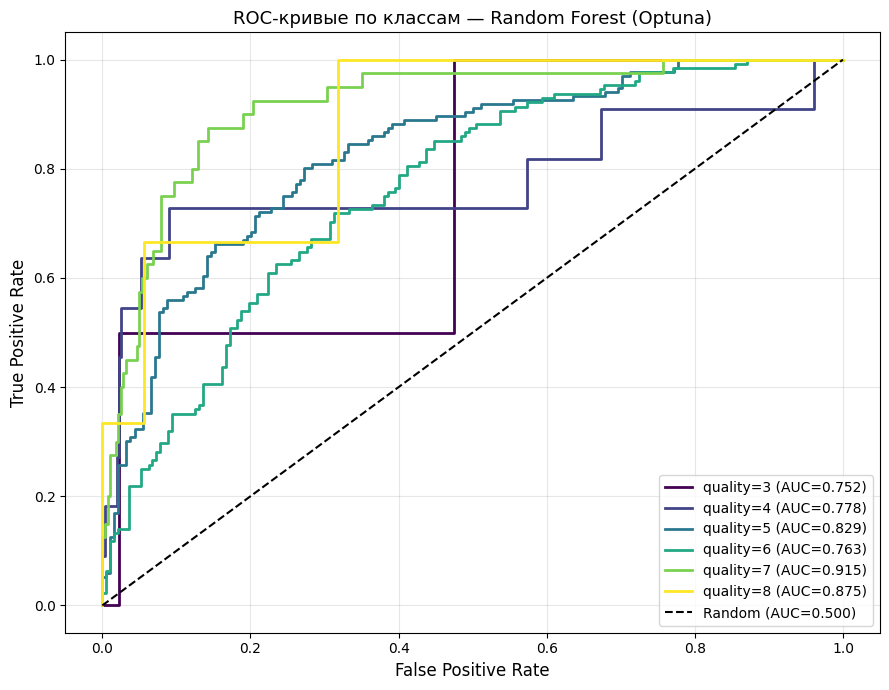

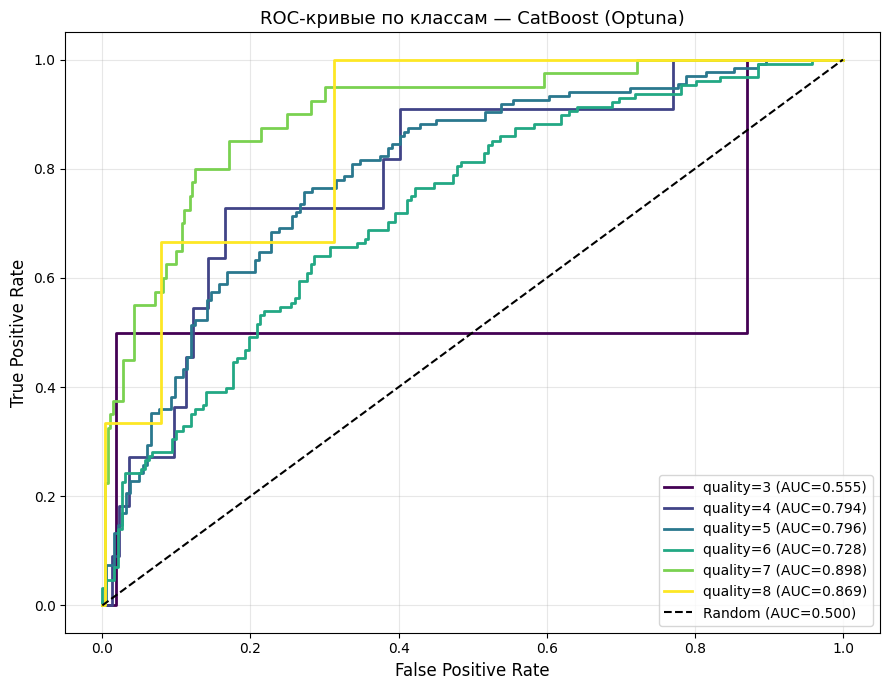

In [45]:
y_test_bin = label_binarize(y_test, classes=range(N_CLASSES))
colors_roc = plt.cm.viridis(np.linspace(0, 1, N_CLASSES))


def plot_roc_curves(y_true_bin, y_proba, model_name):
    fig, ax = plt.subplots(figsize=(9, 7))
    for i in range(N_CLASSES):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
                label=f'quality={le.classes_[i]} (AUC={roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.500)')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'ROC-кривые по классам — {model_name}', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_roc_curves(y_test_bin, y_proba_rf_best,  'Random Forest (Optuna)')
plot_roc_curves(y_test_bin, y_proba_cb_best,  'CatBoost (Optuna)')


> **Вывод:** [Место для вашего вывода — для каких классов AUC наиболее высокий и почему? Как разрыв между классами соотносится с дисбалансом датасета?]


## 4. Анализ пересечения ошибок

> **Hint:** Пересечение ошибок двух моделей показывает «тяжёлые» объекты — те примеры, с которыми не справляются оба алгоритма одновременно. Они же будут выбраны для локальной интерпретации в разделе VI.


In [46]:
idx_all = np.arange(len(y_test))

correct_rf = set(idx_all[y_pred_rf_best == y_test])
correct_cb = set(idx_all[y_pred_cb_best == y_test])
wrong_rf   = set(idx_all[y_pred_rf_best != y_test])
wrong_cb   = set(idx_all[y_pred_cb_best != y_test])

shared_correct = sorted(correct_rf & correct_cb)
shared_wrong   = sorted(wrong_rf   & wrong_cb)
only_rf_wrong  = sorted(wrong_rf   - wrong_cb)
only_cb_wrong  = sorted(wrong_cb   - wrong_rf)

intersection_data = [
    ('Оба правы',           len(shared_correct)),
    ('Оба ошибаются',       len(shared_wrong)),
    ('Только RF ошибается', len(only_rf_wrong)),
    ('Только CB ошибается', len(only_cb_wrong)),
]
inter_df = pd.DataFrame(intersection_data, columns=['Категория', 'Количество'])
print('Анализ пересечения ошибок:')
display(inter_df)

fig = px.bar(
    inter_df, x='Категория', y='Количество',
    text='Количество',
    color='Категория',
    color_discrete_sequence=['seagreen', 'crimson', 'steelblue', 'coral'],
    title='Пересечение ошибок: RF vs CatBoost',
    width=700, height=420,
)
fig.update_traces(textposition='outside')
fig.update_layout(
    title={'x': 0.5, 'xanchor': 'center'},
    showlegend=False,
)
fig.show()

# Выбираем до 10 объектов каждой категории для локального XAI
local_correct_idx = shared_correct[:10]
local_wrong_idx   = shared_wrong[:10]
local_idx         = local_correct_idx + local_wrong_idx

print(f'\nДля локального XAI выбрано:')
print(f'  Верных (общих для RF и CB):   {len(local_correct_idx)}')
print(f'  Ошибочных (общих для RF и CB): {len(local_wrong_idx)}')
print(f'  Итого:                         {len(local_idx)}')


Анализ пересечения ошибок:


,Категория,Количество
0,Оба правы,174
1,Оба ошибаются,100
2,Только RF ошибается,10
3,Только CB ошибается,36



Для локального XAI выбрано:
  Верных (общих для RF и CB):   10
  Ошибочных (общих для RF и CB): 10
  Итого:                         20


> **Вывод:** [Место для вашего вывода — какую долю объектов оба алгоритма классифицируют неверно? О чём это говорит?]


# VI. Интерпретируемость (XAI)

Все методы интерпретации применяются к **оптимизированным моделям** (`rf_best`, `cb_best`). Для методов, требующих выбора одного класса, используется **`TARGET_CLASS_IDX`** (индекс quality=6 — наиболее распространённый класс).

## 1. Глобальная интерпретация

### 1.1 Permutation Importance

> **Hint:** Permutation Importance — это model-agnostic метод: он перемешивает значения признака и измеряет падение метрики. В отличие от встроенной важности деревьев, он учитывает корреляции между признаками.


In [47]:
for model_obj, model_label in [(rf_best, 'Random Forest'), (cb_best, 'CatBoost')]:
    perm_res = permutation_importance(
        model_obj, X_test_scaled, y_test,
        n_repeats=10, random_state=RANDOM_STATE,
        scoring='f1_macro', n_jobs=-1,
    )
    perm_df = pd.DataFrame({
        'feature':    FEATURE_COLS,
        'importance': perm_res.importances_mean,
        'std':        perm_res.importances_std,
    }).sort_values('importance', ascending=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=perm_df['importance'], y=perm_df['feature'],
        orientation='h', marker_color='steelblue',
        error_x=dict(type='data', array=perm_df['std'], visible=True),
    ))
    fig.update_layout(
        title={'text': f'Permutation Importance — {model_label}', 'x': 0.5, 'xanchor': 'center'},
        xaxis_title='Снижение F1 Macro при перемешивании',
        yaxis_title='Признак',
        template='plotly_white', width=800, height=550, showlegend=False,
    )
    fig.show()


> **Вывод:** [Место для вашего вывода — совпадают ли топ-5 признаков у RF и CatBoost? Что это говорит о природе задачи?]


### 1.2 Partial Dependence Plots (PDP) — Random Forest

> **Hint:** PDP показывает усреднённое влияние одного признака на вероятность предсказания конкретного класса при прочих равных условиях. Здесь анализируется класс `quality=6` (`TARGET_CLASS_IDX={TARGET_CLASS_IDX}`).


Топ-5 признаков для PDP: ['sulphates', 'volatile acidity', 'alcohol', 'alc_density_prod', 'vol_fixed_ratio']


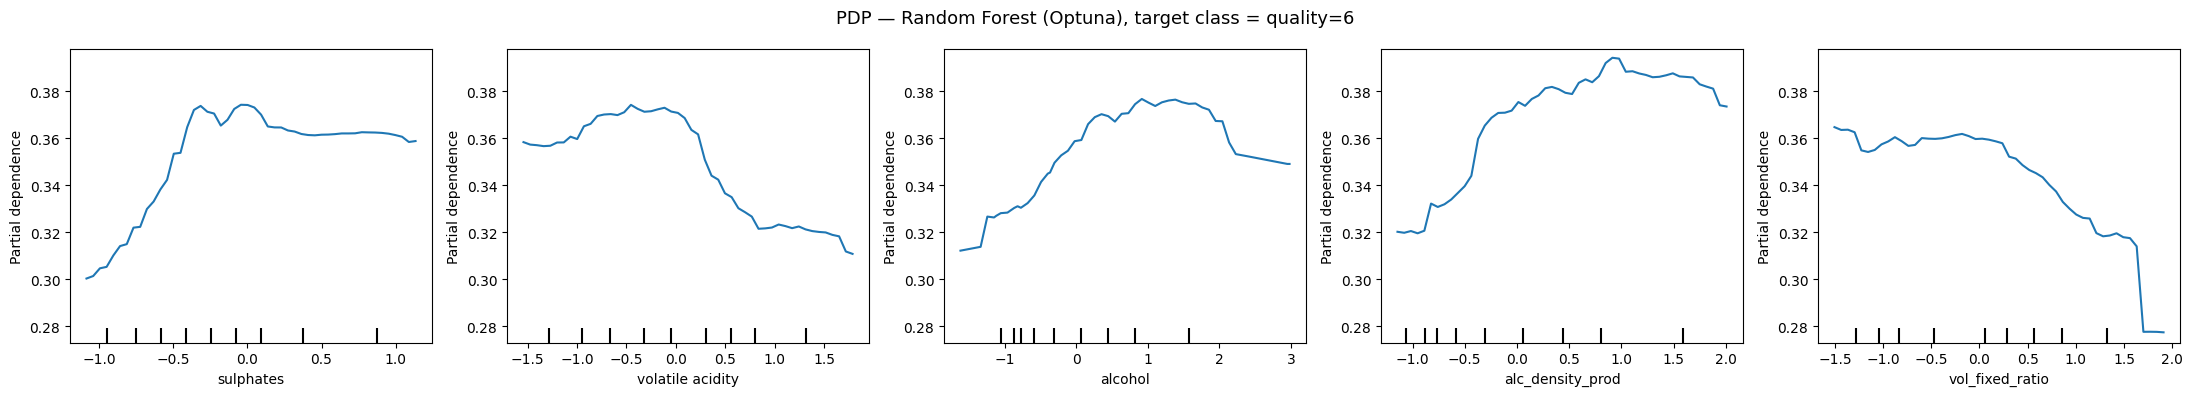

In [48]:
# Топ-5 признаков по Permutation Importance (RF)
perm_rf = permutation_importance(
    rf_best, X_test_scaled, y_test,
    n_repeats=5, random_state=RANDOM_STATE,
    scoring='f1_macro', n_jobs=-1,
)
top5_idx   = np.argsort(perm_rf.importances_mean)[::-1][:5]
top5_names = [FEATURE_COLS[i] for i in top5_idx]
print(f'Топ-5 признаков для PDP: {top5_names}')

fig_pdp, axes_pdp = plt.subplots(1, 5, figsize=(22, 4))
PartialDependenceDisplay.from_estimator(
    rf_best,
    X_test_scaled,
    features=top5_names,
    target=TARGET_CLASS_IDX,
    kind='average',
    ax=axes_pdp,
    grid_resolution=50,
    random_state=RANDOM_STATE,
)
fig_pdp.suptitle(
    f'PDP — Random Forest (Optuna), target class = quality={le.classes_[TARGET_CLASS_IDX]}',
    fontsize=13,
)
plt.tight_layout()
plt.show()


> **Вывод:** [Место для вашего вывода — как влияет каждый из топ-5 признаков на вероятность quality=6? Есть ли нелинейные зависимости?]


### 1.3 SHAP Summary Plot — Random Forest

> **Hint:** SHAP (SHapley Additive exPlanations) — это метод, основанный на теории кооперативных игр. Он вычисляет вклад каждого признака в отклонение предсказания от базового значения (mean). Для мультикласса SHAP-значения вычисляются отдельно для каждого класса — здесь визуализируем класс `TARGET_CLASS_IDX` (quality=6).


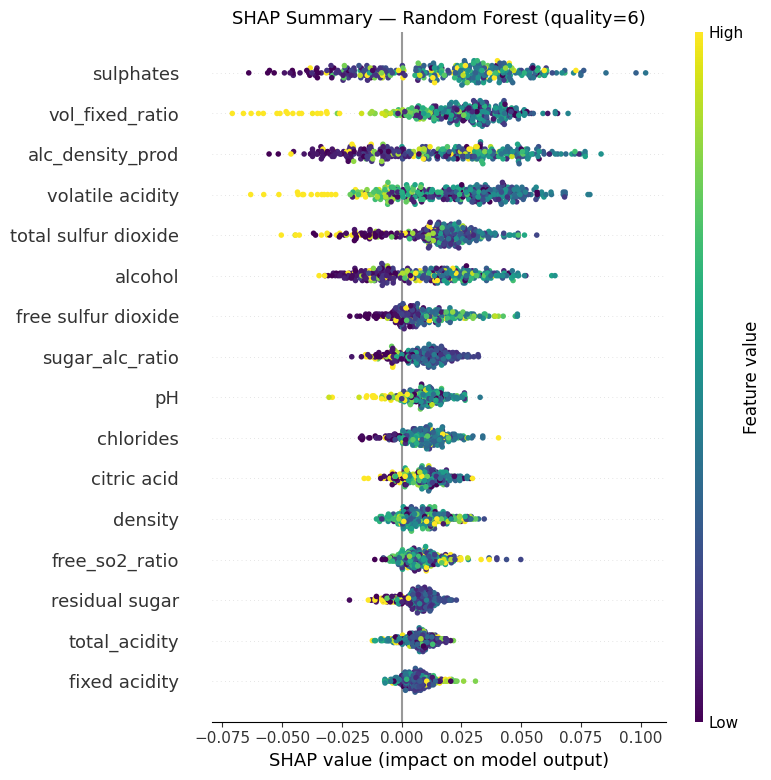

: 

In [ ]:
SHAP_SAMPLE_SIZE = 150
rng_shap = np.random.default_rng(RANDOM_STATE)
shap_idx = rng_shap.choice(len(X_test_scaled), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test_scaled.iloc[shap_idx]

explainer_rf = shap.TreeExplainer(rf_best)
sv_rf = explainer_rf.shap_values(X_shap, check_additivity=False)

# SHAP 0.45+: shap_values возвращает 3D-массив (n_samples, n_features, n_classes),
# старые версии — список массивов (один на класс)
if isinstance(sv_rf, list):
    sv_rf_target = sv_rf[TARGET_CLASS_IDX]
else:
    sv_rf_target = sv_rf[:, :, TARGET_CLASS_IDX]
ev_rf_target = explainer_rf.expected_value[TARGET_CLASS_IDX]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_rf_target,
    X_shap,
    feature_names=FEATURE_COLS,
    cmap=plt.cm.viridis,
    show=False,
)
plt.title(f'SHAP Summary — Random Forest (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=13)
plt.tight_layout()
plt.show()


> **Вывод:** [Место для вашего вывода — какой признак вносит наибольший вклад по SHAP? Совпадает ли с Permutation Importance? Есть ли признаки с двусторонним влиянием?]


### 1.4 SHAP Summary Plot — CatBoost


In [ ]:
explainer_cb = shap.TreeExplainer(cb_best)
sv_cb = explainer_cb.shap_values(X_shap)

# Обработка обоих форматов: список или 3D-массив
if isinstance(sv_cb, list):
    sv_cb_target = sv_cb[TARGET_CLASS_IDX]
    ev_cb_target = explainer_cb.expected_value[TARGET_CLASS_IDX]
else:
    sv_cb_target = sv_cb[:, :, TARGET_CLASS_IDX]
    ev_cb_target = explainer_cb.expected_value[TARGET_CLASS_IDX]

plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_cb_target,
    X_shap,
    feature_names=FEATURE_COLS,
    cmap=plt.cm.viridis,
    show=False,
)
plt.title(f'SHAP Summary — CatBoost (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=13)
plt.tight_layout()
plt.show()


> **Вывод:** [Место для вашего вывода — совпадают ли SHAP-профили RF и CatBoost? В чём принципиальная разница в интерпретации двух разных алгоритмов?]


## 2. Локальная интерпретация

Для локальной интерпретации используем **20 объектов**: 10 верно классифицированных и 10 ошибочно классифицированных — **общих для обеих моделей** (выбранных в разделе V.4).

### 2.1 SHAP Heatmap (20 объектов)

> **Hint:** SHAP Heatmap визуализирует матрицу SHAP-значений для всех 20 выбранных объектов. Строки — объекты, столбцы — признаки. Позволяет увидеть, за счёт каких признаков модель правильно или неправильно классифицирует каждый объект.


In [ ]:
X_local = X_test_scaled.iloc[local_idx].reset_index(drop=True)
labels_local = [
    f'✅ q={le.classes_[y_test[i]]}' if i in local_correct_idx
    else f'❌ q={le.classes_[y_test[i]]}'
    for i in local_idx
]

# RF SHAP Heatmap
sv_rf_local = sv_rf_target[local_idx]
exp_rf_local = shap.Explanation(
    values=sv_rf_local,
    base_values=np.full(len(local_idx), ev_rf_target),
    data=X_local.values,
    feature_names=FEATURE_COLS,
)
plt.figure(figsize=(14, 7))
shap.plots.heatmap(exp_rf_local, cmap=plt.cm.viridis, show=False)
plt.title(f'SHAP Heatmap — Random Forest (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=12)
plt.tight_layout()
plt.show()

# CatBoost SHAP Heatmap
sv_cb_local = sv_cb_target[local_idx]
exp_cb_local = shap.Explanation(
    values=sv_cb_local,
    base_values=np.full(len(local_idx), ev_cb_target),
    data=X_local.values,
    feature_names=FEATURE_COLS,
)
plt.figure(figsize=(14, 7))
shap.plots.heatmap(exp_cb_local, cmap=plt.cm.viridis, show=False)
plt.title(f'SHAP Heatmap — CatBoost (quality={le.classes_[TARGET_CLASS_IDX]})', fontsize=12)
plt.tight_layout()
plt.show()


> **Вывод:** [Место для вашего вывода — какие признаки ведут себя согласованно на всех 20 объектах? Чем отличается паттерн для верных и ошибочных объектов?]


### 2.2 SHAP Waterfall (точечный анализ)

> **Hint:** Waterfall plot — детальное объяснение отдельного объекта: показывает, насколько каждый признак «сдвигает» предсказание от базового значения (E[f(X)]) к финальному предсказанию f(x). Анализируем один верный и один ошибочный объект.


In [ ]:
for sample_pos, label in [(0, 'верно классифицированный'), (len(local_correct_idx), 'ошибочно классифицированный')]:
    orig_idx = local_idx[sample_pos]
    true_q   = le.classes_[y_test[orig_idx]]
    pred_q_rf = le.classes_[y_pred_rf_best[orig_idx]]

    print(f'\nОбъект #{orig_idx} ({label}): истинный класс = {true_q}, RF предсказал = {pred_q_rf}')

    # RF Waterfall
    exp_rf_single = shap.Explanation(
        values=sv_rf_target[orig_idx],
        base_values=ev_rf_target,
        data=X_test_scaled.iloc[orig_idx].values,
        feature_names=FEATURE_COLS,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_rf_single, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — RF ({label}, quality={true_q})', fontsize=12)
    plt.tight_layout()
    plt.show()

    # CatBoost Waterfall
    exp_cb_single = shap.Explanation(
        values=sv_cb_target[orig_idx],
        base_values=ev_cb_target,
        data=X_test_scaled.iloc[orig_idx].values,
        feature_names=FEATURE_COLS,
    )
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(exp_cb_single, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — CatBoost ({label}, quality={true_q})', fontsize=12)
    plt.tight_layout()
    plt.show()


> **Вывод:** [Место для вашего вывода — за счёт каких признаков произошла ошибка классификации? Согласуются ли объяснения RF и CatBoost для одного и того же объекта?]


### 2.3 LIME (локальная суррогатная интерпретация)

> **Hint:** LIME строит локальную линейную модель в окрестности конкретного объекта. В отличие от SHAP, LIME — более универсален и работает как чёрный ящик. Сравниваем объяснения LIME и SHAP для одних и тех же объектов.


In [ ]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=FEATURE_COLS,
    class_names=CLASS_NAMES,
    mode='classification',
    random_state=RANDOM_STATE,
)


def explain_with_lime(model, model_name, sample_idx, label):
    '''Строит LIME-объяснение для одного объекта и визуализирует его.'''
    true_q = le.classes_[y_test[sample_idx]]
    exp = lime_explainer.explain_instance(
        data_row=X_test_scaled.iloc[sample_idx].values,
        predict_fn=model.predict_proba,
        num_features=10,
        top_labels=1,
    )
    print(f'\nLIME — {model_name} ({label}, истинный класс quality={true_q})')
    exp.show_in_notebook(show_all=False)


correct_sample_idx = local_idx[0]
wrong_sample_idx   = local_idx[len(local_correct_idx)]

for sample_idx, label in [
    (correct_sample_idx, 'верно классифицированный'),
    (wrong_sample_idx,   'ошибочно классифицированный'),
]:
    explain_with_lime(rf_best,  'Random Forest', sample_idx, label)
    explain_with_lime(cb_best,  'CatBoost',      sample_idx, label)

print('✅ LIME объяснения построены')


> **Вывод:** [Место для вашего вывода — совпадают ли объяснения LIME и SHAP для одних и тех же объектов? Насколько можно доверять LIME как суррогатной модели?]


# VII. Выводы

## 1. Обзор результатов

> **Вывод:** [Место для вашего вывода — кратко опишите полученные результаты: какая модель лучшая, каковы итоговые метрики?]

## 2. Сравнение природы алгоритмов

> **Вывод:** [Место для вашего вывода — в чём принципиальная разница между Random Forest (бэггинг) и CatBoost (бустинг) в контексте данной задачи? Что выгоднее применять и когда?]

## 3. Интерпретируемость и XAI

> **Вывод:** [Место для вашего вывода — какие признаки являются ключевыми для определения качества вина по результатам SHAP, PDP и Permutation Importance? Есть ли расхождения между методами?]

## 4. Проблема дисбаланса классов

> **Вывод:** [Место для вашего вывода — как дисбаланс классов (крайне мало вин качества 3 и 8) повлиял на качество классификации? Какие метрики лучше всего отразили эту проблему?]

## 5. Выводы по анализу ошибок

> **Вывод:** [Место для вашего вывода — что общего у объектов, с которыми обе модели ошибаются? Можно ли найти закономерность в «тяжёлых» объектах по их SHAP-профилям?]
